In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (classification_report, roc_curve,
                             auc, ConfusionMatrixDisplay, roc_auc_score,
                             cohen_kappa_score)

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
from src.config.dir_config import Process_Dir
df = pd.read_csv(Process_Dir / 'onlinefraud_cleaned.csv')
df.head(10)

,hour_of_day,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,C1231006815,M1979787155,1,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,C1666544295,M2044282225,1,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.0,0.00,C1305486145,C553264065,0,0.00,181.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,C840083671,C38997010,0,0.00,21363.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,C2048537720,M1230701703,1,0.00,0.00,0
5,1,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,C90045638,M573487274,1,0.00,0.00,0
6,1,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,C154988899,M408069119,1,0.00,0.00,0
7,1,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,C1912850431,M633326333,1,0.00,0.00,0
8,1,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,C1265012928,M1176932104,1,1353.36,0.00,0
9,1,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,C712410124,C195600860,0,0.00,6886.98,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df = pd.get_dummies(df, columns= ['type'], drop_first= True, dtype= int)

In [6]:
df

,hour_of_day,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,C1231006815,M1979787155,1,0.0,0.000000e+00,0,0,0,1,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,C1666544295,M2044282225,1,0.0,0.000000e+00,0,0,0,1,0
2,1,181.00,181.00,0.00,0.00,0.00,C1305486145,C553264065,0,0.0,1.810000e+02,1,0,0,0,1
3,1,181.00,181.00,0.00,21182.00,0.00,C840083671,C38997010,0,0.0,2.136300e+04,1,1,0,0,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,C2048537720,M1230701703,1,0.0,0.000000e+00,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,23,339682.13,339682.13,0.00,0.00,339682.13,C786484425,C776919290,0,0.0,0.000000e+00,1,1,0,0,0
6362616,23,6311409.28,6311409.28,0.00,0.00,0.00,C1529008245,C1881841831,0,0.0,6.311409e+06,1,0,0,0,1
6362617,23,6311409.28,6311409.28,0.00,68488.84,6379898.11,C1162922333,C1365125890,0,0.0,1.000000e-02,1,1,0,0,0
6362618,23,850002.52,850002.52,0.00,0.00,0.00,C1685995037,C2080388513,0,0.0,8.500025e+05,1,0,0,0,1


In [7]:
X = df.drop(['nameOrig', 'nameDest', 'errorBalanceOrig', 'errorBalanceDest'], axis= 1)
y = X.pop('isFraud')

# train+val and test
x_temp, x_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.1765,  # ~15% total
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

# Fit only on training data
x_train_scaled = scaler.fit_transform(x_train)

# Use the same scaler for val and test
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [8]:
x_train_scaled.shape, x_val_scaled.shape, x_test_scaled.shape

((4453674, 11), (954553, 11), (954393, 11))

In [9]:
lr_model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    )

cat_model = CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )

lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    )

# Logistic Regression
lr_model.fit(x_train_scaled, y_train)

# Random Forest
rf_model.fit(x_train_scaled, y_train)

# XGBoost
xgb_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    verbose= False
)

# CatBoost
cat_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
)

# Light GBM
lgbm_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    eval_metric='auc',
)

[LightGBM] [Info] Number of positive: 5749, number of negative: 4447925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 4453674, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Save models

In [11]:
os.makedirs("main_models/without_proxy", exist_ok=True)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost" : xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

for name, model in models.items():
    filename = f"main_models/without_proxy/{name}.pkl"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

print("All models saved!")

Saved: main_models/without_proxy/Logistic Regression.pkl
Saved: main_models/without_proxy/Random Forest.pkl
Saved: main_models/without_proxy/XGBoost.pkl
Saved: main_models/without_proxy/LightGBM.pkl
Saved: main_models/without_proxy/CatBoost.pkl
All models saved!


#### Load models

In [ ]:
lr_model = joblib.load("main_models/without_proxy/Logistic Regression.pkl")
rf_model = joblib.load("main_models/without_proxy/Random Forest.pkl")
xgb_model = joblib.load("main_models/without_proxy/XGBoost.pkl")
cat_model = joblib.load("main_models/without_proxy/CatBoost.pkl")
lgbm_model = joblib.load("main_models/without_proxy/LightGBM.pkl")

#### Evaluate

In [12]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost" : xgb_model,
    "CatBoost": cat_model,
    "LightGBM": lgbm_model
}

In [13]:
for name, model in models.items():
    y_pred = model.predict(x_test_scaled)
    y_pred_proba = model.predict_proba(x_val_scaled)[:, 1]
    y_pred_kappa = cohen_kappa_score(y_test, y_pred)
    auc_score = roc_auc_score(y_val, y_pred_proba)

    print(name)
    print(f"kappa score: {y_pred_kappa:.4f}")
    print(f"auc score: {auc_score:.4f}")
    print(
        classification_report(
            y_test,
            y_pred,
            digits= 4,
            labels=[0, 1],
            target_names=['Non-Fraud', 'Fraud']
        )
    )
    print()

Logistic Regression
kappa score: 0.0452
auc score: 0.9908
              precision    recall  f1-score   support

   Non-Fraud     0.9999    0.9514    0.9750    953161
       Fraud     0.0244    0.9407    0.0476      1232

    accuracy                         0.9514    954393
   macro avg     0.5122    0.9461    0.5113    954393
weighted avg     0.9987    0.9514    0.9738    954393


Random Forest
kappa score: 0.8783
auc score: 0.9988
              precision    recall  f1-score   support

   Non-Fraud     0.9997    1.0000    0.9999    953161
       Fraud     0.9771    0.7979    0.8785      1232

    accuracy                         0.9997    954393
   macro avg     0.9884    0.8989    0.9392    954393
weighted avg     0.9997    0.9997    0.9997    954393


XGBoost
kappa score: 0.8697
auc score: 0.9999
              precision    recall  f1-score   support

   Non-Fraud     0.9998    0.9998    0.9998    953161
       Fraud     0.8633    0.8766    0.8699      1232

    accuracy            

#### Find best Thresholds for each model

In [14]:
def find_best_threshold(y_true, y_pred_score):
    thresholds = np.arange(0.01, 1.0, 0.01)

    best_f1 = 0
    best_threshold = 0

    for t in thresholds:
        y_pred = (y_pred_score >= t).astype(int)

        f1 = f1_score(y_true, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1

Logistic Regression
kappa score: 0.4444
best threshold: 0.99
              precision    recall  f1-score   support

   Non-Fraud     0.9995    0.9985    0.9990    953161
       Fraud     0.3492    0.6144    0.4453      1232

    accuracy                         0.9980    954393
   macro avg     0.6743    0.8065    0.7222    954393
weighted avg     0.9987    0.9980    0.9983    954393




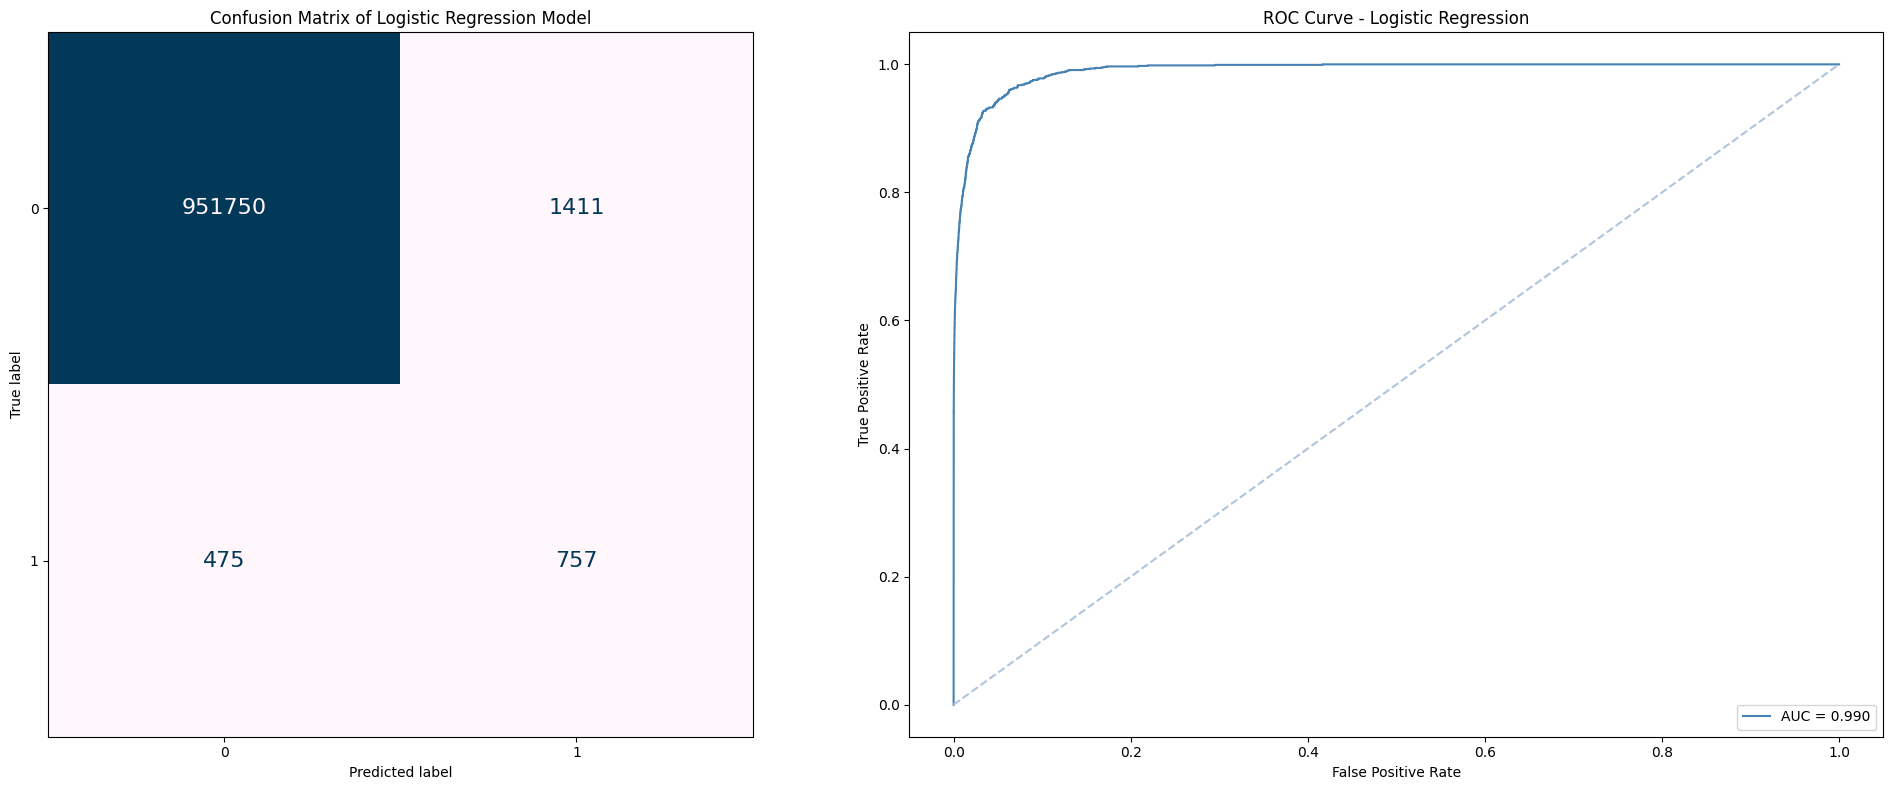

Random Forest
kappa score: 0.8847
best threshold: 0.39
              precision    recall  f1-score   support

   Non-Fraud     0.9998    1.0000    0.9999    953161
       Fraud     0.9691    0.8141    0.8849      1232

    accuracy                         0.9997    954393
   macro avg     0.9844    0.9070    0.9424    954393
weighted avg     0.9997    0.9997    0.9997    954393




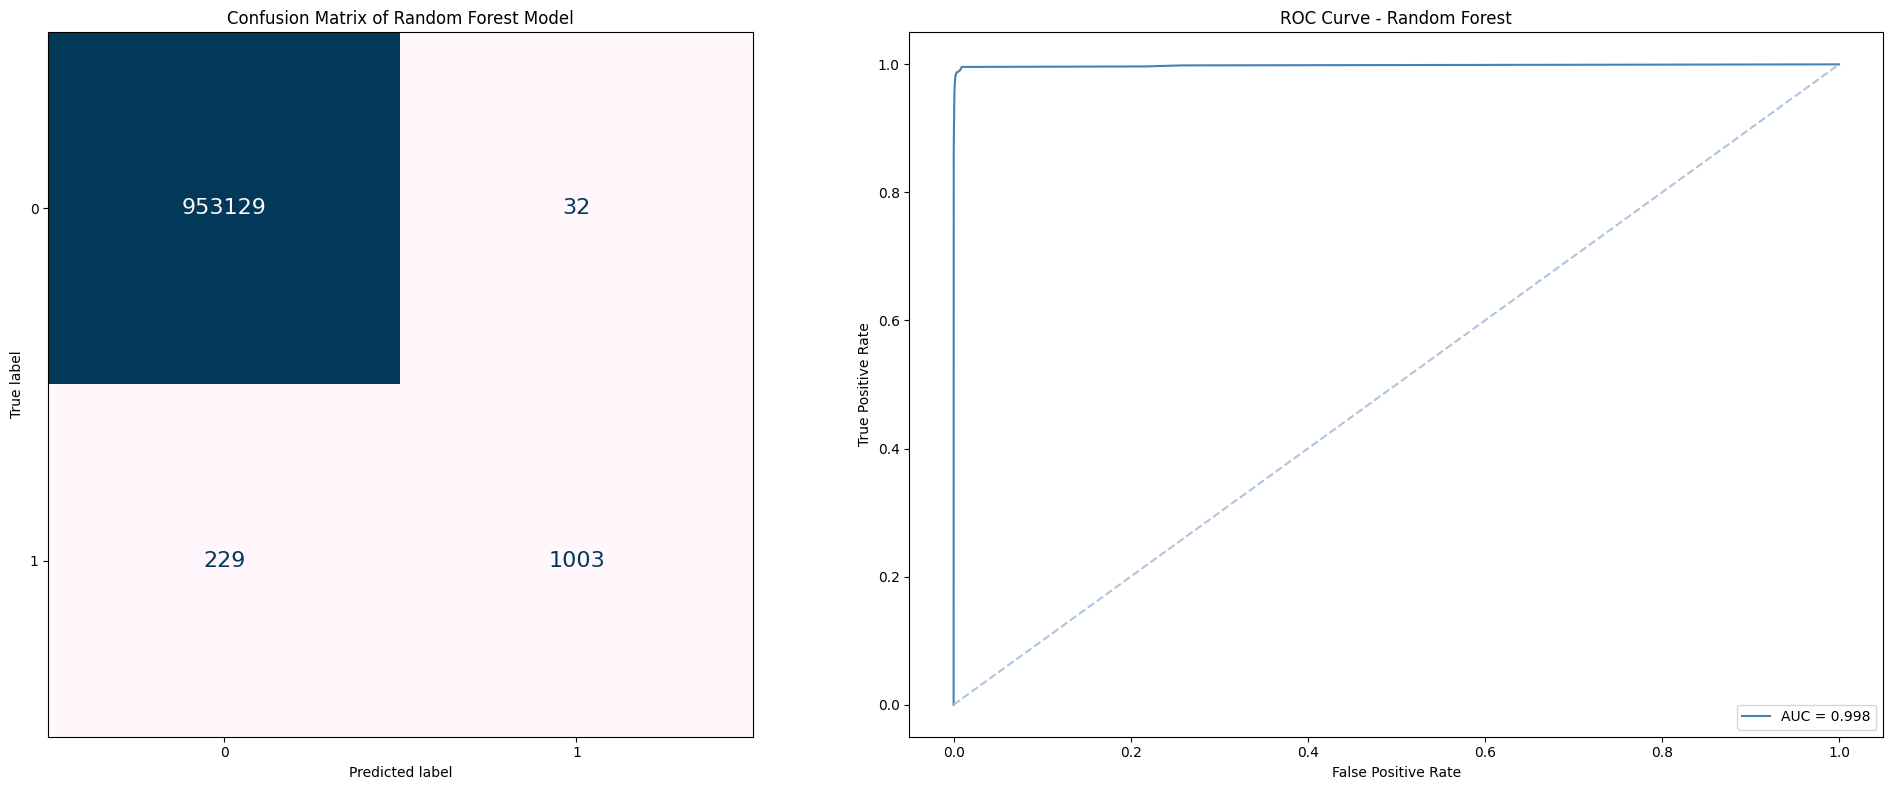

XGBoost
kappa score: 0.8935
best threshold: 0.73
              precision    recall  f1-score   support

   Non-Fraud     0.9998    0.9999    0.9999    953161
       Fraud     0.9392    0.8523    0.8936      1232

    accuracy                         0.9997    954393
   macro avg     0.9695    0.9261    0.9467    954393
weighted avg     0.9997    0.9997    0.9997    954393




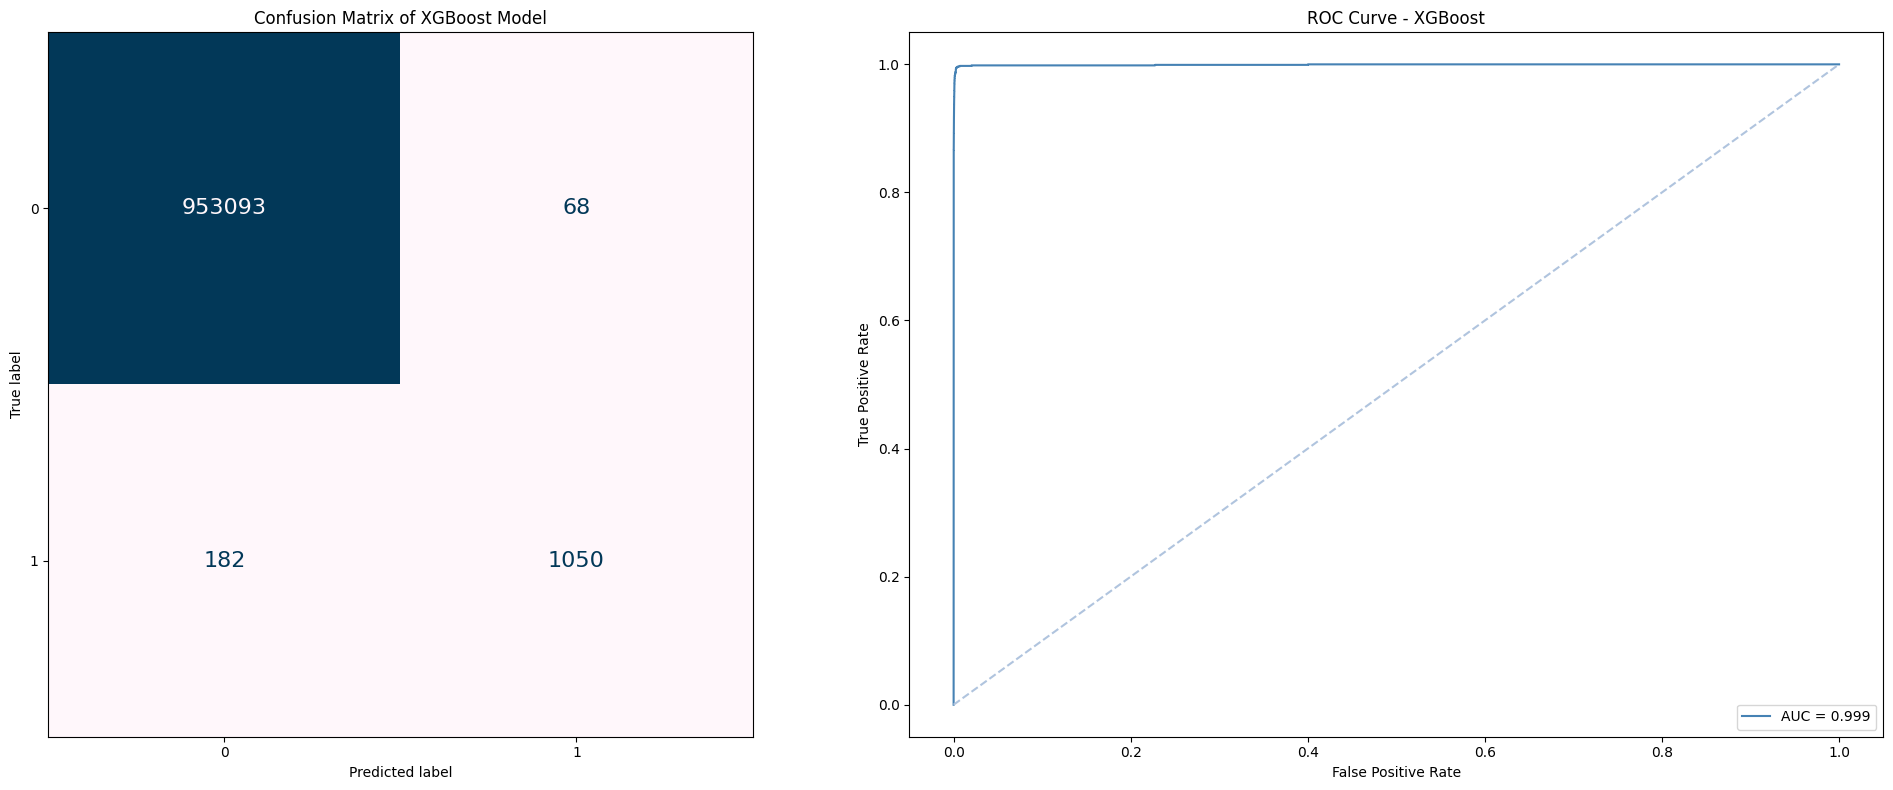

CatBoost
kappa score: 0.8751
best threshold: 0.99
              precision    recall  f1-score   support

   Non-Fraud     0.9998    0.9999    0.9998    953161
       Fraud     0.9069    0.8458    0.8753      1232

    accuracy                         0.9997    954393
   macro avg     0.9533    0.9228    0.9376    954393
weighted avg     0.9997    0.9997    0.9997    954393




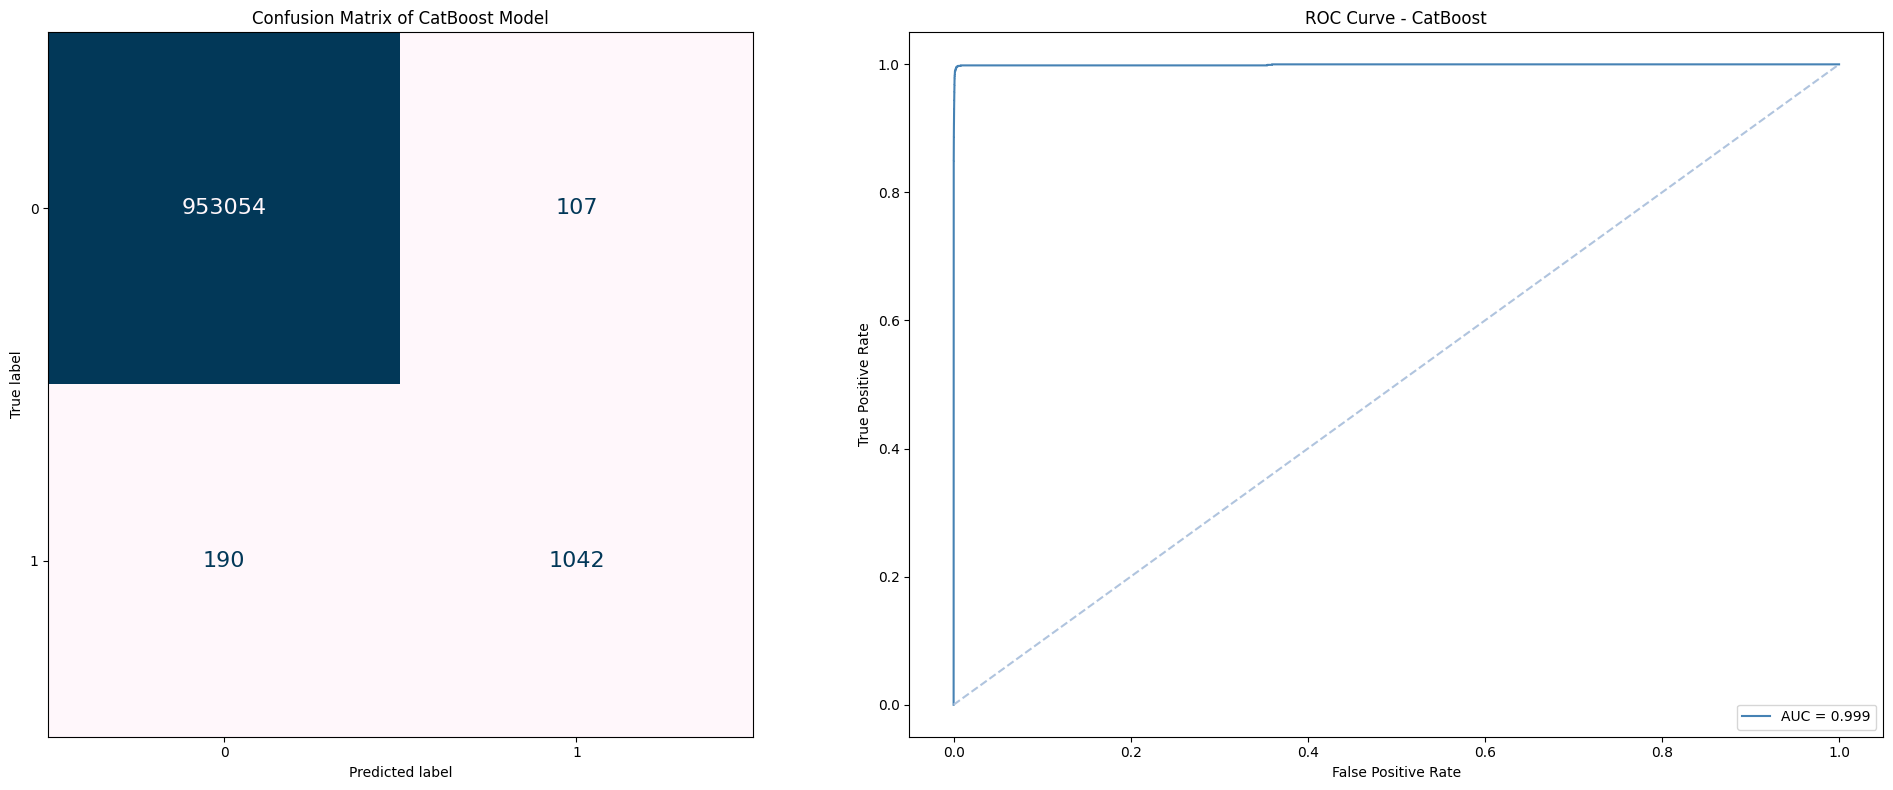

LightGBM
kappa score: 0.8981
best threshold: 0.99
              precision    recall  f1-score   support

   Non-Fraud     0.9998    0.9999    0.9999    953161
       Fraud     0.9366    0.8628    0.8982      1232

    accuracy                         0.9997    954393
   macro avg     0.9682    0.9314    0.9490    954393
weighted avg     0.9997    0.9997    0.9997    954393




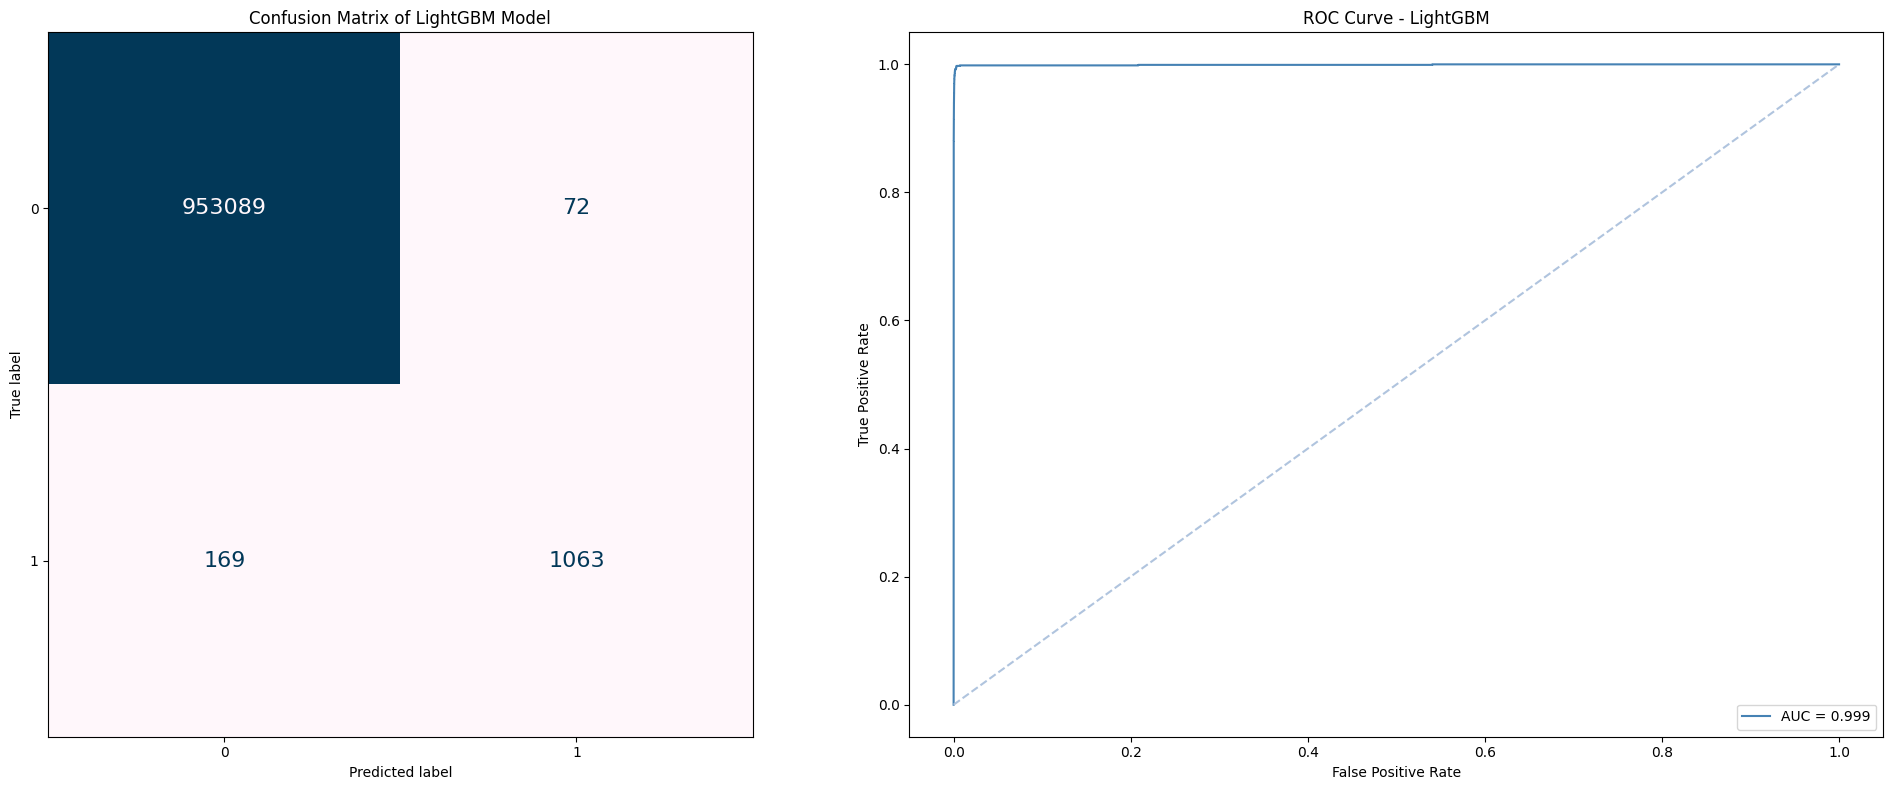

In [15]:
for name, model in models.items():
    y_pred_score = model.predict_proba(x_test_scaled)[:, 1]
    best_threshold, best_f1 = find_best_threshold(y_test, y_pred_score)
    y_pred = (y_pred_score >= best_threshold).astype(int)
    y_pred_kappa = cohen_kappa_score(y_test, y_pred)

    print(name)
    print(f"kappa score: {y_pred_kappa:.4f}")
    print(f"best threshold: {best_threshold:.2f}")
    print(
        classification_report(
            y_test,
            y_pred,
            digits= 4,
            labels=[0, 1],
            target_names=['Non-Fraud', 'Fraud']
        )
    )
    print()

    fig, ax = plt.subplots(1, 2, figsize=(20,8))

    # Confusion Matrix
    ax[0].set_title(f'Confusion Matrix of {name} Model')
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        colorbar=False,
        values_format='',
        cmap='PuBu',
        ax=ax[0],
        text_kw={'fontsize': 16}
    )
    ax[0].grid(False)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_score)
    roc_auc = auc(fpr, tpr)

    ax[1].set_title(f'ROC Curve - {name}')
    ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
    ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
    ax[1].legend(loc='lower right')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_xlabel('False Positive Rate')

    plt.tight_layout()
    plt.show()

#### The table of before and after apply thresholds

| Model | AUC | Kappa (Before) | Precision (Before) | Recall (Before) | F1 (Before) | Threshold | Kappa (After) | Precision (After) | Recall (After) | F1 (After) |
|---------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|
| Logistic Regression | 0.9908 | 0.0452 | 0.0244 | 0.9407 | 0.0476 | 0.99 | 0.4444 | 0.3492 | 0.6144 | 0.4453 |
| Random Forest | 0.9988 | 0.8783 | 0.9771 | 0.7979 | 0.8785 | 0.39 | 0.8847 | 0.9691 | 0.8141 | 0.8849 |
| XGBoost | 0.9999 | 0.8697 | 0.8633 | 0.8766 | 0.8699 | 0.73 | 0.8935 | 0.9392 | 0.8523 | 0.8936 |
| CatBoost | 0.9999 | 0.4818 | 0.3188 | 0.9943 | 0.4829 | 0.99 | 0.8751 | 0.9069 | 0.8458 | 0.8753 |
| LightGBM | 0.9999 | 0.5509 | 0.3821 | 0.9927 | 0.5518 | 0.99 | 0.8981 | 0.9366 | 0.8628 | 0.8982 |

- Note: Logistic Regression doesn't have feature importance

In [ ]:
# Random Forest
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
2      oldbalanceOrg    0.302734
3     newbalanceOrig    0.167797
1             amount    0.153614
10     type_TRANSFER    0.070928
4     oldbalanceDest    0.060031
5     newbalanceDest    0.055567
6   is_Merchant_Dest    0.051137
0        hour_of_day    0.048370
7      type_CASH_OUT    0.046722
9       type_PAYMENT    0.042735
8         type_DEBIT    0.000365


In [21]:
# XGBoost
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
3     newbalanceOrig    0.343547
6   is_Merchant_Dest    0.196373
9       type_PAYMENT    0.141995
7      type_CASH_OUT    0.094241
10     type_TRANSFER    0.084900
2      oldbalanceOrg    0.047454
1             amount    0.028370
5     newbalanceDest    0.022985
0        hour_of_day    0.016826
8         type_DEBIT    0.013292
4     oldbalanceDest    0.010017


In [22]:
# CatBoost
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': cat_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
2      oldbalanceOrg   25.488690
1             amount   21.002415
3     newbalanceOrig   12.155933
7      type_CASH_OUT   11.576807
0        hour_of_day    8.109210
4     oldbalanceDest    6.352759
5     newbalanceDest    5.753560
10     type_TRANSFER    5.325334
9       type_PAYMENT    4.225910
8         type_DEBIT    0.009383
6   is_Merchant_Dest    0.000000


In [23]:
# Light GBM
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
1             amount        1805
2      oldbalanceOrg        1533
5     newbalanceDest         801
4     oldbalanceDest         651
0        hour_of_day         606
3     newbalanceOrig         189
7      type_CASH_OUT         138
10     type_TRANSFER         134
6   is_Merchant_Dest         102
8         type_DEBIT          27
9       type_PAYMENT          14
